# Decision Tree Model — Clean Retraining


- The model is trained only on pre-risk shipment features.
- Gini, Entropy, and Log Loss criteria are compared.
- Updated model, metrics, and report files are regenerated.

## 1. Imports and paths

In [1]:
from pathlib import Path
import itertools
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TRAINING_SAMPLE_SIZE = 60000

# This notebook is expected to be saved in ml/notebooks.
# The path logic also works when the notebook is run from the project root.
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks" and CURRENT_DIR.parent.name == "ml":
    ML_DIR = CURRENT_DIR.parent
elif (CURRENT_DIR / "ml").exists():
    ML_DIR = CURRENT_DIR / "ml"
else:
    ML_DIR = CURRENT_DIR.parent

DATA_PATH = ML_DIR / "data" / "processed" / "cleaned_dataset.csv"
MODELS_DIR = ML_DIR / "models"

MODEL_PATH = MODELS_DIR / "import_risk_decision_tree.joblib"
METRICS_PATH = MODELS_DIR / "decision_tree_metrics.json"
REPORT_PATH = MODELS_DIR / "decision_tree_report.txt"

print("ML directory:", ML_DIR)
print("Dataset path:", DATA_PATH)
print("Models directory:", MODELS_DIR)

ML directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml
Dataset path: C:\Users\admin\Desktop\import-risk-analysis-system\ml\data\processed\cleaned_dataset.csv
Models directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models


## 2. Safe feature set

The Decision Tree must use only pre-risk shipment features. Tax-derived band features are intentionally excluded.

In [2]:
FEATURE_COLUMNS = [
    "price_usd",
    "weight_kg",
    "length_m",
    "width_m",
    "height_m",
    "volume_m3",
    "max_dimension_m",
    "dimension_sum_m",
    "density_kg_m3",
    "value_per_kg",
    "value_per_m3",
]

LEAKAGE_FEATURES = {"tax", "tax_ratio", "tax_band", "tax_ratio_band"}
used_leakage_features = sorted(LEAKAGE_FEATURES.intersection(FEATURE_COLUMNS))

if used_leakage_features:
    raise ValueError(f"Leakage features are still used: {used_leakage_features}")

print("Features used in Decision Tree:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

print("\nLeakage check passed: tax-derived features are not used.")

Features used in Decision Tree:
- price_usd
- weight_kg
- length_m
- width_m
- height_m
- volume_m3
- max_dimension_m
- dimension_sum_m
- density_kg_m3
- value_per_kg
- value_per_m3

Leakage check passed: tax-derived features are not used.


## 3. Load and validate dataset

In [3]:
def load_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path}")

    return pd.read_csv(path)


def limit_dataset_size(df, max_rows):
    if len(df) <= max_rows:
        return df.reset_index(drop=True)

    sampled_df, _ = train_test_split(
        df,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=df["risk"],
    )

    return sampled_df.reset_index(drop=True)


def validate_training_columns(df):
    required_columns = set(FEATURE_COLUMNS + ["risk"])
    missing_columns = sorted(required_columns.difference(df.columns))

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")


df = load_dataset(DATA_PATH)
df = limit_dataset_size(df, TRAINING_SAMPLE_SIZE)
validate_training_columns(df)

print(f"Rows used: {len(df):,}")
print("Risk distribution:")
display(df["risk"].value_counts().to_frame("count"))

Rows used: 60,000
Risk distribution:


,count
risk,
LOW RISK,51000
HIGH RISK,9000


## 4. Prepare train/test split

The split remains 80/20 and is stratified by the target label.

In [4]:
X = df[FEATURE_COLUMNS].copy()
y = df["risk"].map({
    "HIGH RISK": 1,
    "LOW RISK": 0,
})

if y.isna().any():
    raise ValueError("Risk column contains invalid values.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 48,000
Test rows: 12,000


## 5. Baseline model

The baseline predicts the most frequent class. The Decision Tree should be compared against this baseline.

In [5]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = round(accuracy_score(y_test, baseline_predictions), 4)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.85


## 6. Train Decision Tree models

The model is compared across Gini, Entropy, and Log Loss. A modest tuning grid is used to keep the tree realistic and reduce overfitting.

In [6]:
CRITERIA = ["gini", "entropy", "log_loss"]

PARAM_GRID = {
    "criterion": CRITERIA,
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [100, 200, 300],
    "min_samples_leaf": [50, 100, 150],
    "class_weight": [None, "balanced"],
}


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(
            y_test,
            y_pred,
            target_names=["LOW RISK", "HIGH RISK"],
            zero_division=0,
        ),
    }


def build_feature_importance(model):
    return sorted(
        [
            {
                "feature": feature,
                "importance": round(float(importance), 6),
            }
            for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_)
        ],
        key=lambda item: item["importance"],
        reverse=True,
    )


grid_results = []

keys = list(PARAM_GRID.keys())
for values in itertools.product(*(PARAM_GRID[key] for key in keys)):
    params = dict(zip(keys, values))

    model = DecisionTreeClassifier(
        **params,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)

    grid_results.append({
        "model": model,
        "params": params,
        "metrics": metrics,
    })

print(f"Trained {len(grid_results)} Decision Tree configurations.")

Trained 216 Decision Tree configurations.


## 7. Select final model

The final saved model is selected by highest F1 Score first, then highest Accuracy.

In [ ]:
best_result = max(
    grid_results,
    key=lambda item: (item["metrics"]["f1_score"], item["metrics"]["accuracy"]),
)

best_model = best_result["model"]
best_params = best_result["params"]
best_metrics = best_result["metrics"]

criterion_results = []
for criterion in CRITERIA:
    best_for_criterion = max(
        [item for item in grid_results if item["params"]["criterion"] == criterion],
        key=lambda item: (item["metrics"]["f1_score"], item["metrics"]["accuracy"]),
    )

    criterion_results.append({
        "criterion": criterion,
        "accuracy": best_for_criterion["metrics"]["accuracy"],
        "precision": best_for_criterion["metrics"]["precision"],
        "recall": best_for_criterion["metrics"]["recall"],
        "f1_score": best_for_criterion["metrics"]["f1_score"],
        "best_params": best_for_criterion["params"],
    })

metrics = {
    **best_metrics,
    "criterion": best_params["criterion"],
    "best_params": best_params,
    "baseline_accuracy": baseline_accuracy,
    "feature_importance": build_feature_importance(best_model),
    "features_used": FEATURE_COLUMNS,
    "rows_used": len(X),
    "test_rows": len(X_test),
    "model": "Decision Tree",
    "criterion_results": criterion_results,
    "model_note": (
        "Decision Tree was trained without PCA for the final model. "
        "The final tree was trained only on pre-risk shipment features. "
       "Tax-derived band features were removed to avoid label leakage. "
        "to avoid label leakage. "
        "Gini, Entropy, and Log Loss criteria were compared, and the final saved model "
        "is the best-performing configuration based on F1 Score and Accuracy."
    ),
}

print("Best parameters:")
print(best_params)

print("\nFinal model metrics:")
print({
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "baseline_accuracy": metrics["baseline_accuracy"],
})

Best parameters:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 100, 'min_samples_leaf': 50, 'class_weight': 'balanced'}

Final model metrics:
{'accuracy': 0.7822, 'precision': 0.3981, 'recall': 0.8839, 'f1_score': 0.549, 'baseline_accuracy': 0.85}


## 8. Criterion comparison

,criterion,accuracy,precision,recall,f1_score,best_params
0,gini,0.7822,0.3981,0.8839,0.5490,"{'criterion': 'gini', 'max_depth': 4, 'min_sam..."
1,entropy,0.7775,0.3933,0.8911,0.5458,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."
2,log_loss,0.7775,0.3933,0.8911,0.5458,"{'criterion': 'log_loss', 'max_depth': 5, 'min..."


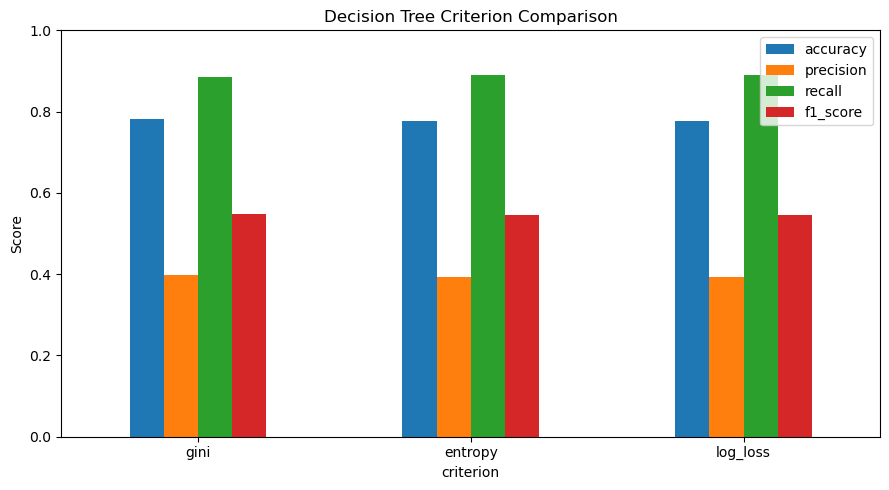

In [8]:
criterion_df = pd.DataFrame(criterion_results)
display(criterion_df[["criterion", "accuracy", "precision", "recall", "f1_score", "best_params"]])

criterion_plot_df = criterion_df.set_index("criterion")[["accuracy", "precision", "recall", "f1_score"]]
criterion_plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Decision Tree Criterion Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Confusion matrix and classification report

Confusion matrix:
[[7795, 2405], [209, 1591]]


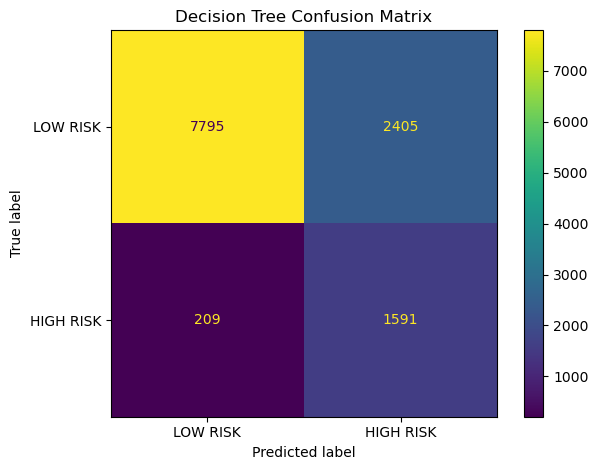

Classification report:
              precision    recall  f1-score   support

    LOW RISK       0.97      0.76      0.86     10200
   HIGH RISK       0.40      0.88      0.55      1800

    accuracy                           0.78     12000
   macro avg       0.69      0.82      0.70     12000
weighted avg       0.89      0.78      0.81     12000



In [10]:
import numpy as np

print("Confusion matrix:")
print(metrics["confusion_matrix"])

cm = np.array(metrics["confusion_matrix"])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["LOW RISK", "HIGH RISK"],
)

display.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification report:")
print(metrics["classification_report"])

## 10. Feature importance

,feature,importance
0,value_per_m3,0.697901
1,price_usd,0.285948
2,value_per_kg,0.016151
3,weight_kg,0.000000
4,length_m,0.000000
5,width_m,0.000000
6,height_m,0.000000
7,volume_m3,0.000000
8,max_dimension_m,0.000000
9,dimension_sum_m,0.000000


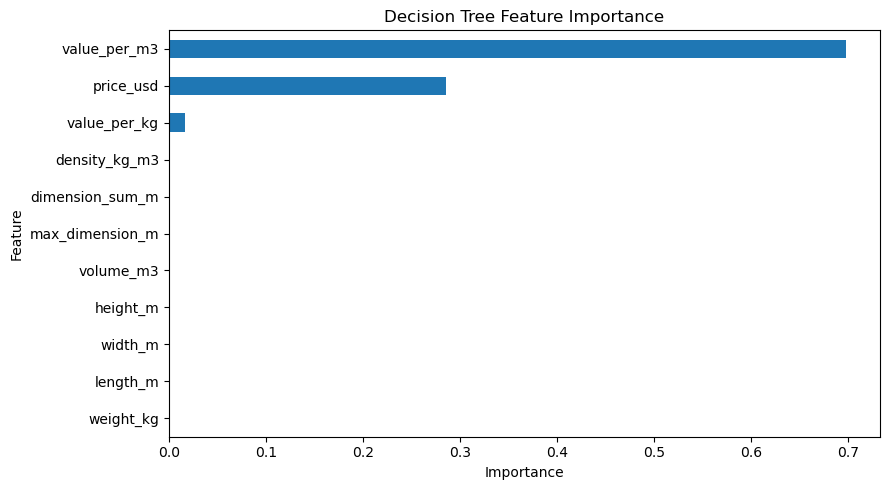

In [12]:
from IPython.display import display as show

feature_importance_df = pd.DataFrame(metrics["feature_importance"])
show(feature_importance_df)

feature_importance_df.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Save updated model, metrics, and report

In [13]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

with METRICS_PATH.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics, metrics_file, indent=2)

with REPORT_PATH.open("w", encoding="utf-8") as report_file:
    report_file.write("Decision Tree Evaluation\n")
    report_file.write("PCA was tested but not selected for the final model.\n")
    report_file.write("The final Decision Tree was trained only on pre-risk shipment features.\n")
    report_file.write("Tax-derived band features were removed to avoid label leakage.\n")
    report_file.write("The model was compared across gini, entropy, and log_loss criteria.\n")
    report_file.write(f"Features: {', '.join(FEATURE_COLUMNS)}\n\n")

    report_file.write(f"Best Criterion: {metrics['criterion']}\n")
    report_file.write(f"Best Parameters: {metrics['best_params']}\n")
    report_file.write(f"Accuracy: {metrics['accuracy']}\n")
    report_file.write(f"Baseline Accuracy: {metrics['baseline_accuracy']}\n")
    report_file.write(f"Precision: {metrics['precision']}\n")
    report_file.write(f"Recall: {metrics['recall']}\n")
    report_file.write(f"F1 Score: {metrics['f1_score']}\n")
    report_file.write(f"Rows Used: {metrics['rows_used']}\n")
    report_file.write(f"Test Rows: {metrics['test_rows']}\n")
    report_file.write(f"Confusion Matrix: {metrics['confusion_matrix']}\n\n")

    report_file.write("Criterion Comparison:\n")
    for result in metrics["criterion_results"]:
        report_file.write(
            f"- {result['criterion']}: "
            f"accuracy={result['accuracy']}, "
            f"precision={result['precision']}, "
            f"recall={result['recall']}, "
            f"f1={result['f1_score']}, "
            f"best_params={result['best_params']}\n"
        )

    report_file.write("\nFeature Importance:\n")
    for item in metrics["feature_importance"]:
        report_file.write(f"- {item['feature']}: {item['importance']}\n")

    report_file.write("\nClassification Report:\n")
    report_file.write(metrics["classification_report"])

print("Saved updated Decision Tree outputs:")
print("-", MODEL_PATH)
print("-", METRICS_PATH)
print("-", REPORT_PATH)

Saved updated Decision Tree outputs:
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\import_risk_decision_tree.joblib
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\decision_tree_metrics.json
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\decision_tree_report.txt


## Conclusion

The Decision Tree model was retrained on the updated cleaned dataset using only realistic pre-risk shipment features.

The final model was compared across Gini, Entropy, and Log Loss criteria, while using a shallow and controlled tree configuration to reduce overfitting.

The final outputs were regenerated:
- `ml/models/import_risk_decision_tree.joblib`
- `ml/models/decision_tree_metrics.json`
- `ml/models/decision_tree_report.txt`